In [1]:
from gmres_mgs import gmres_mgs as gmres
import numpy as np
import scipy as sp
import scipy.linalg as la
import matplotlib.pyplot as plt
from common import set_figure

# Problem 1

In [2]:
m = 200
A = (0.5/np.sqrt(m))*np.random.randn(m,m) + 2.0*np.eye(m)
(W,V)=la.eig(A)
print('minimum eigenvalue: {}'.format(np.abs(W).min()))
print('maximum eigenvalue: {}'.format(np.abs(W).max()))

minimum eigenvalue: 1.5192071176002808
maximum eigenvalue: 2.468849918027526


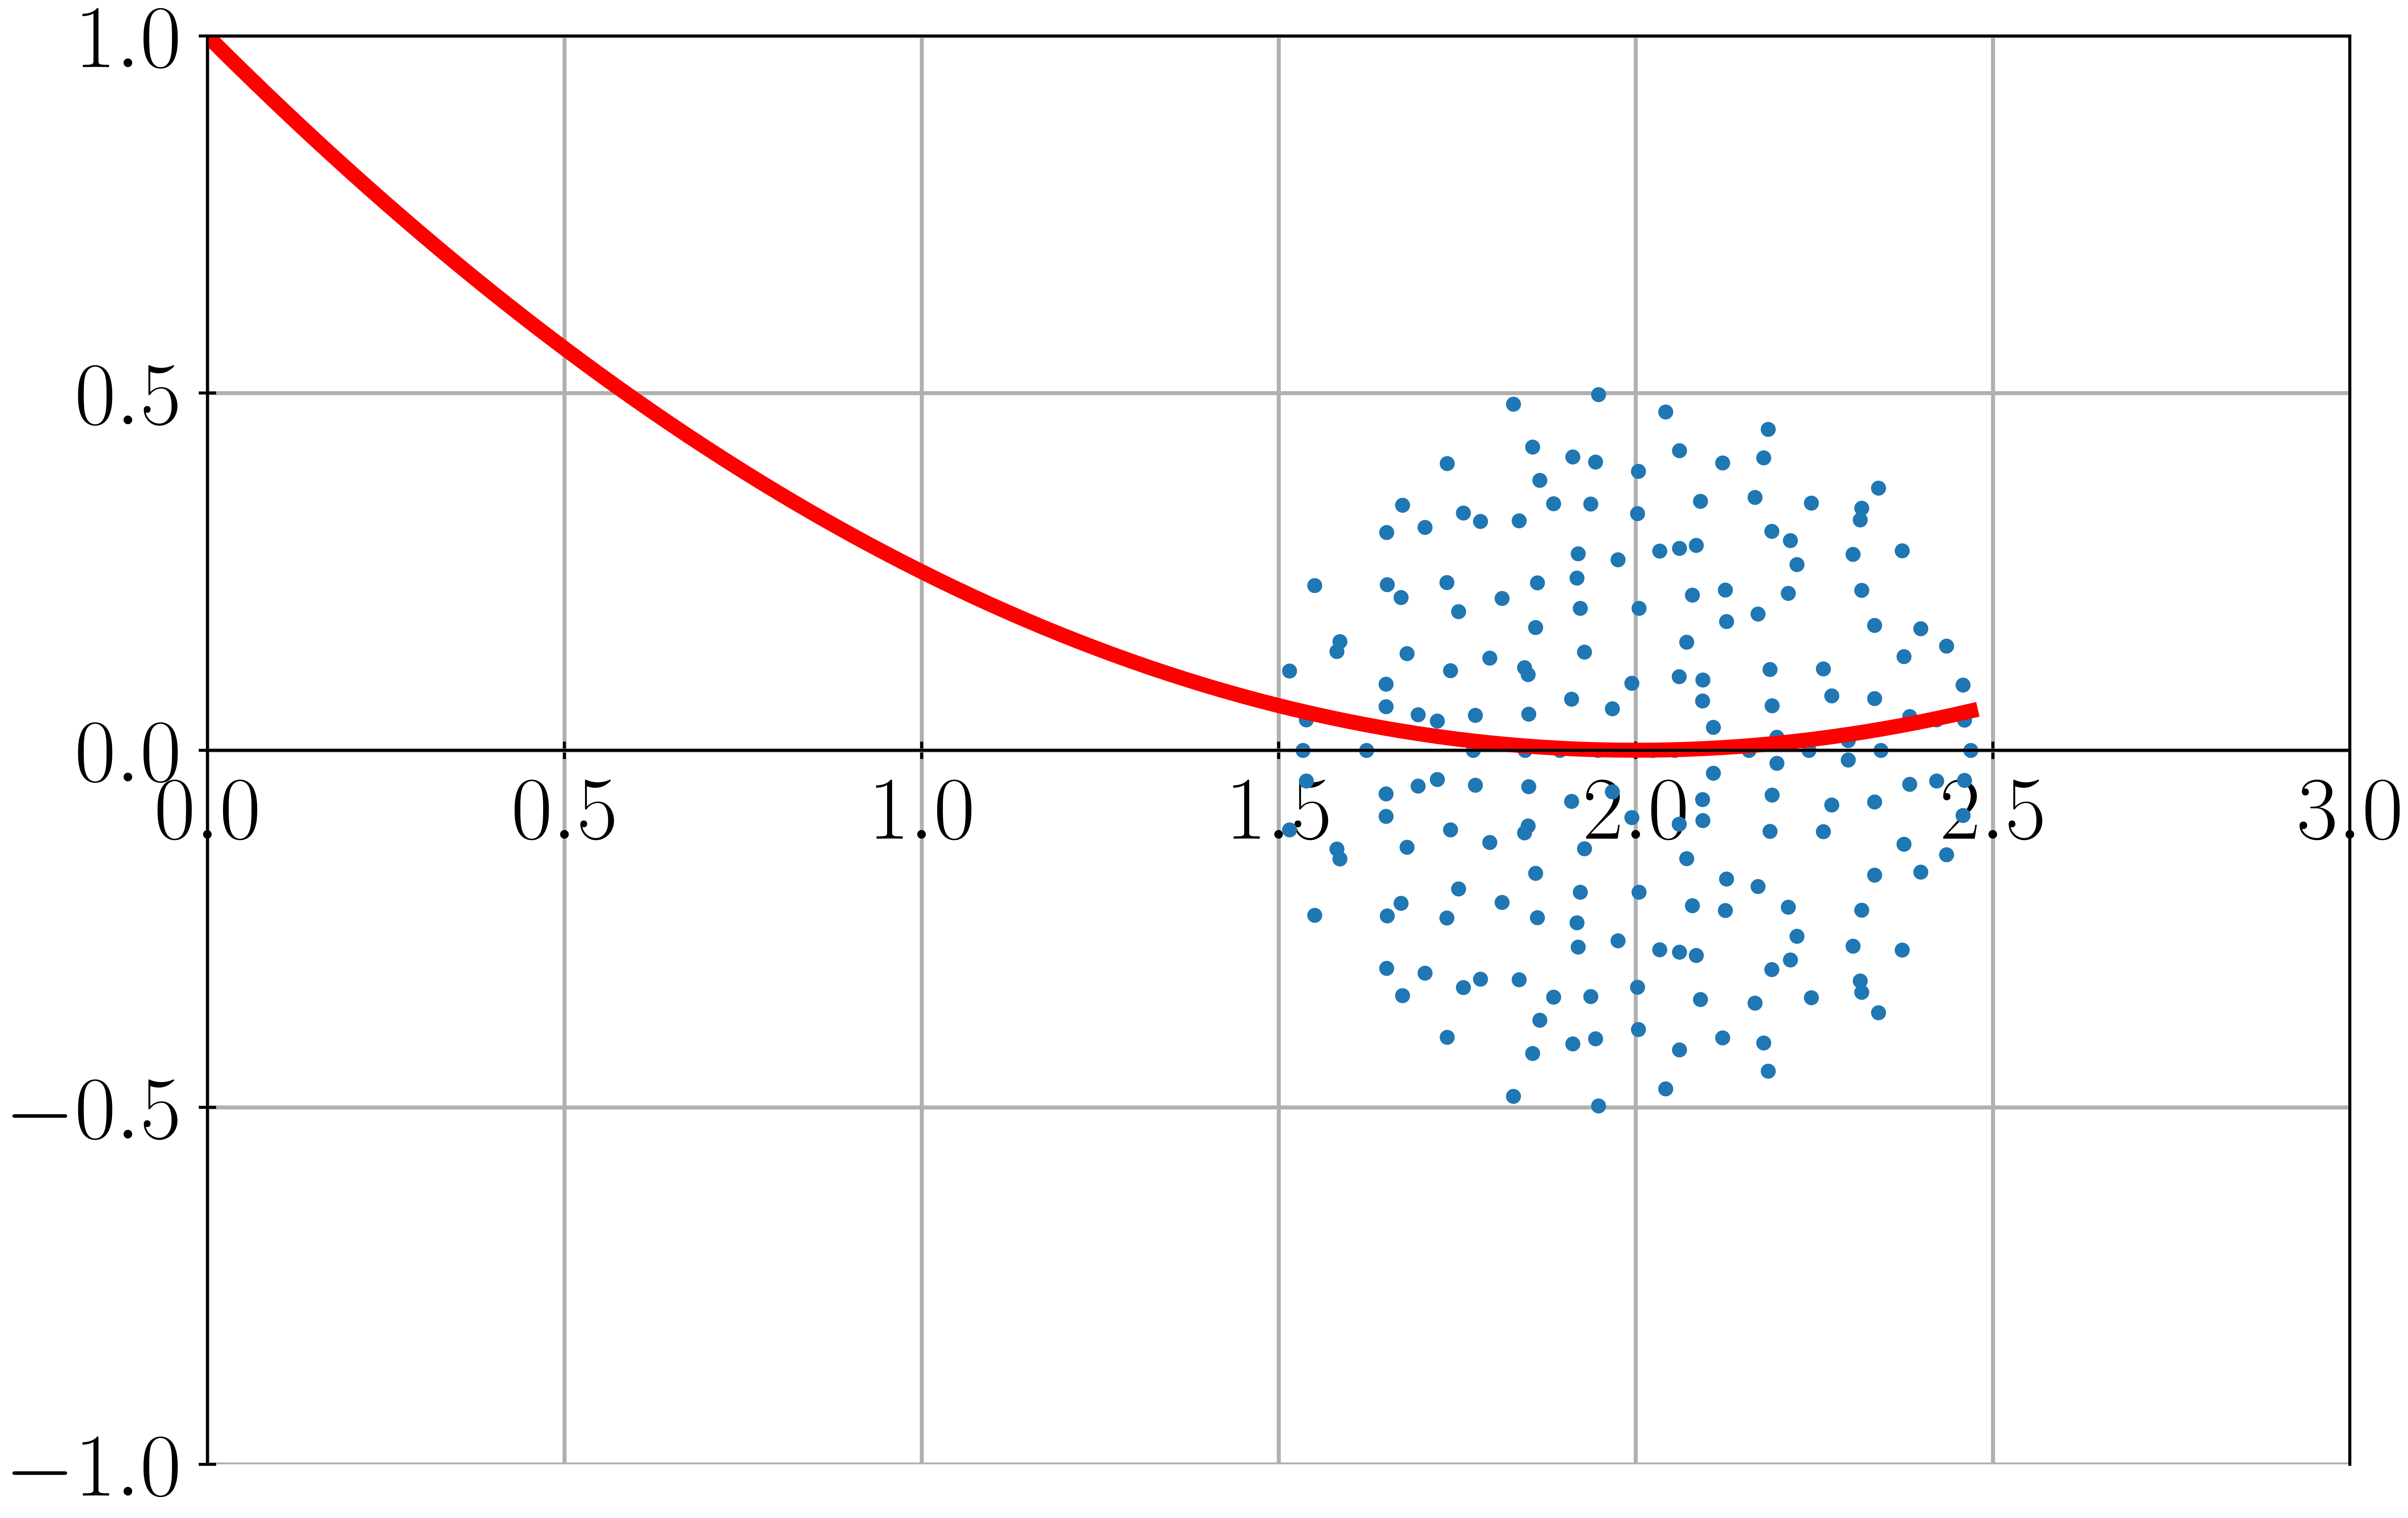

In [3]:
plt.plot(W.real, W.imag, 'o', ms=2)

plt.axis('scaled')
plt.axis([0,3, -1, 1])
plt.gca().spines['bottom'].set_position('zero')
plt.grid(True)

if True:
    def p(z, n):
        return (1 - z/2)**n
    
    z = np.linspace(0, np.abs(W).max(), 100)
    plt.plot(z, p(z, 2), 'r-', lw=3)

In [4]:
b = np.ones((A.shape[0],))
x0 = np.random.rand(len(b))

res = []
x = gmres(A, b, x0=x0, tol=1e-12, restrt=None, maxiter=None, residuals=res)

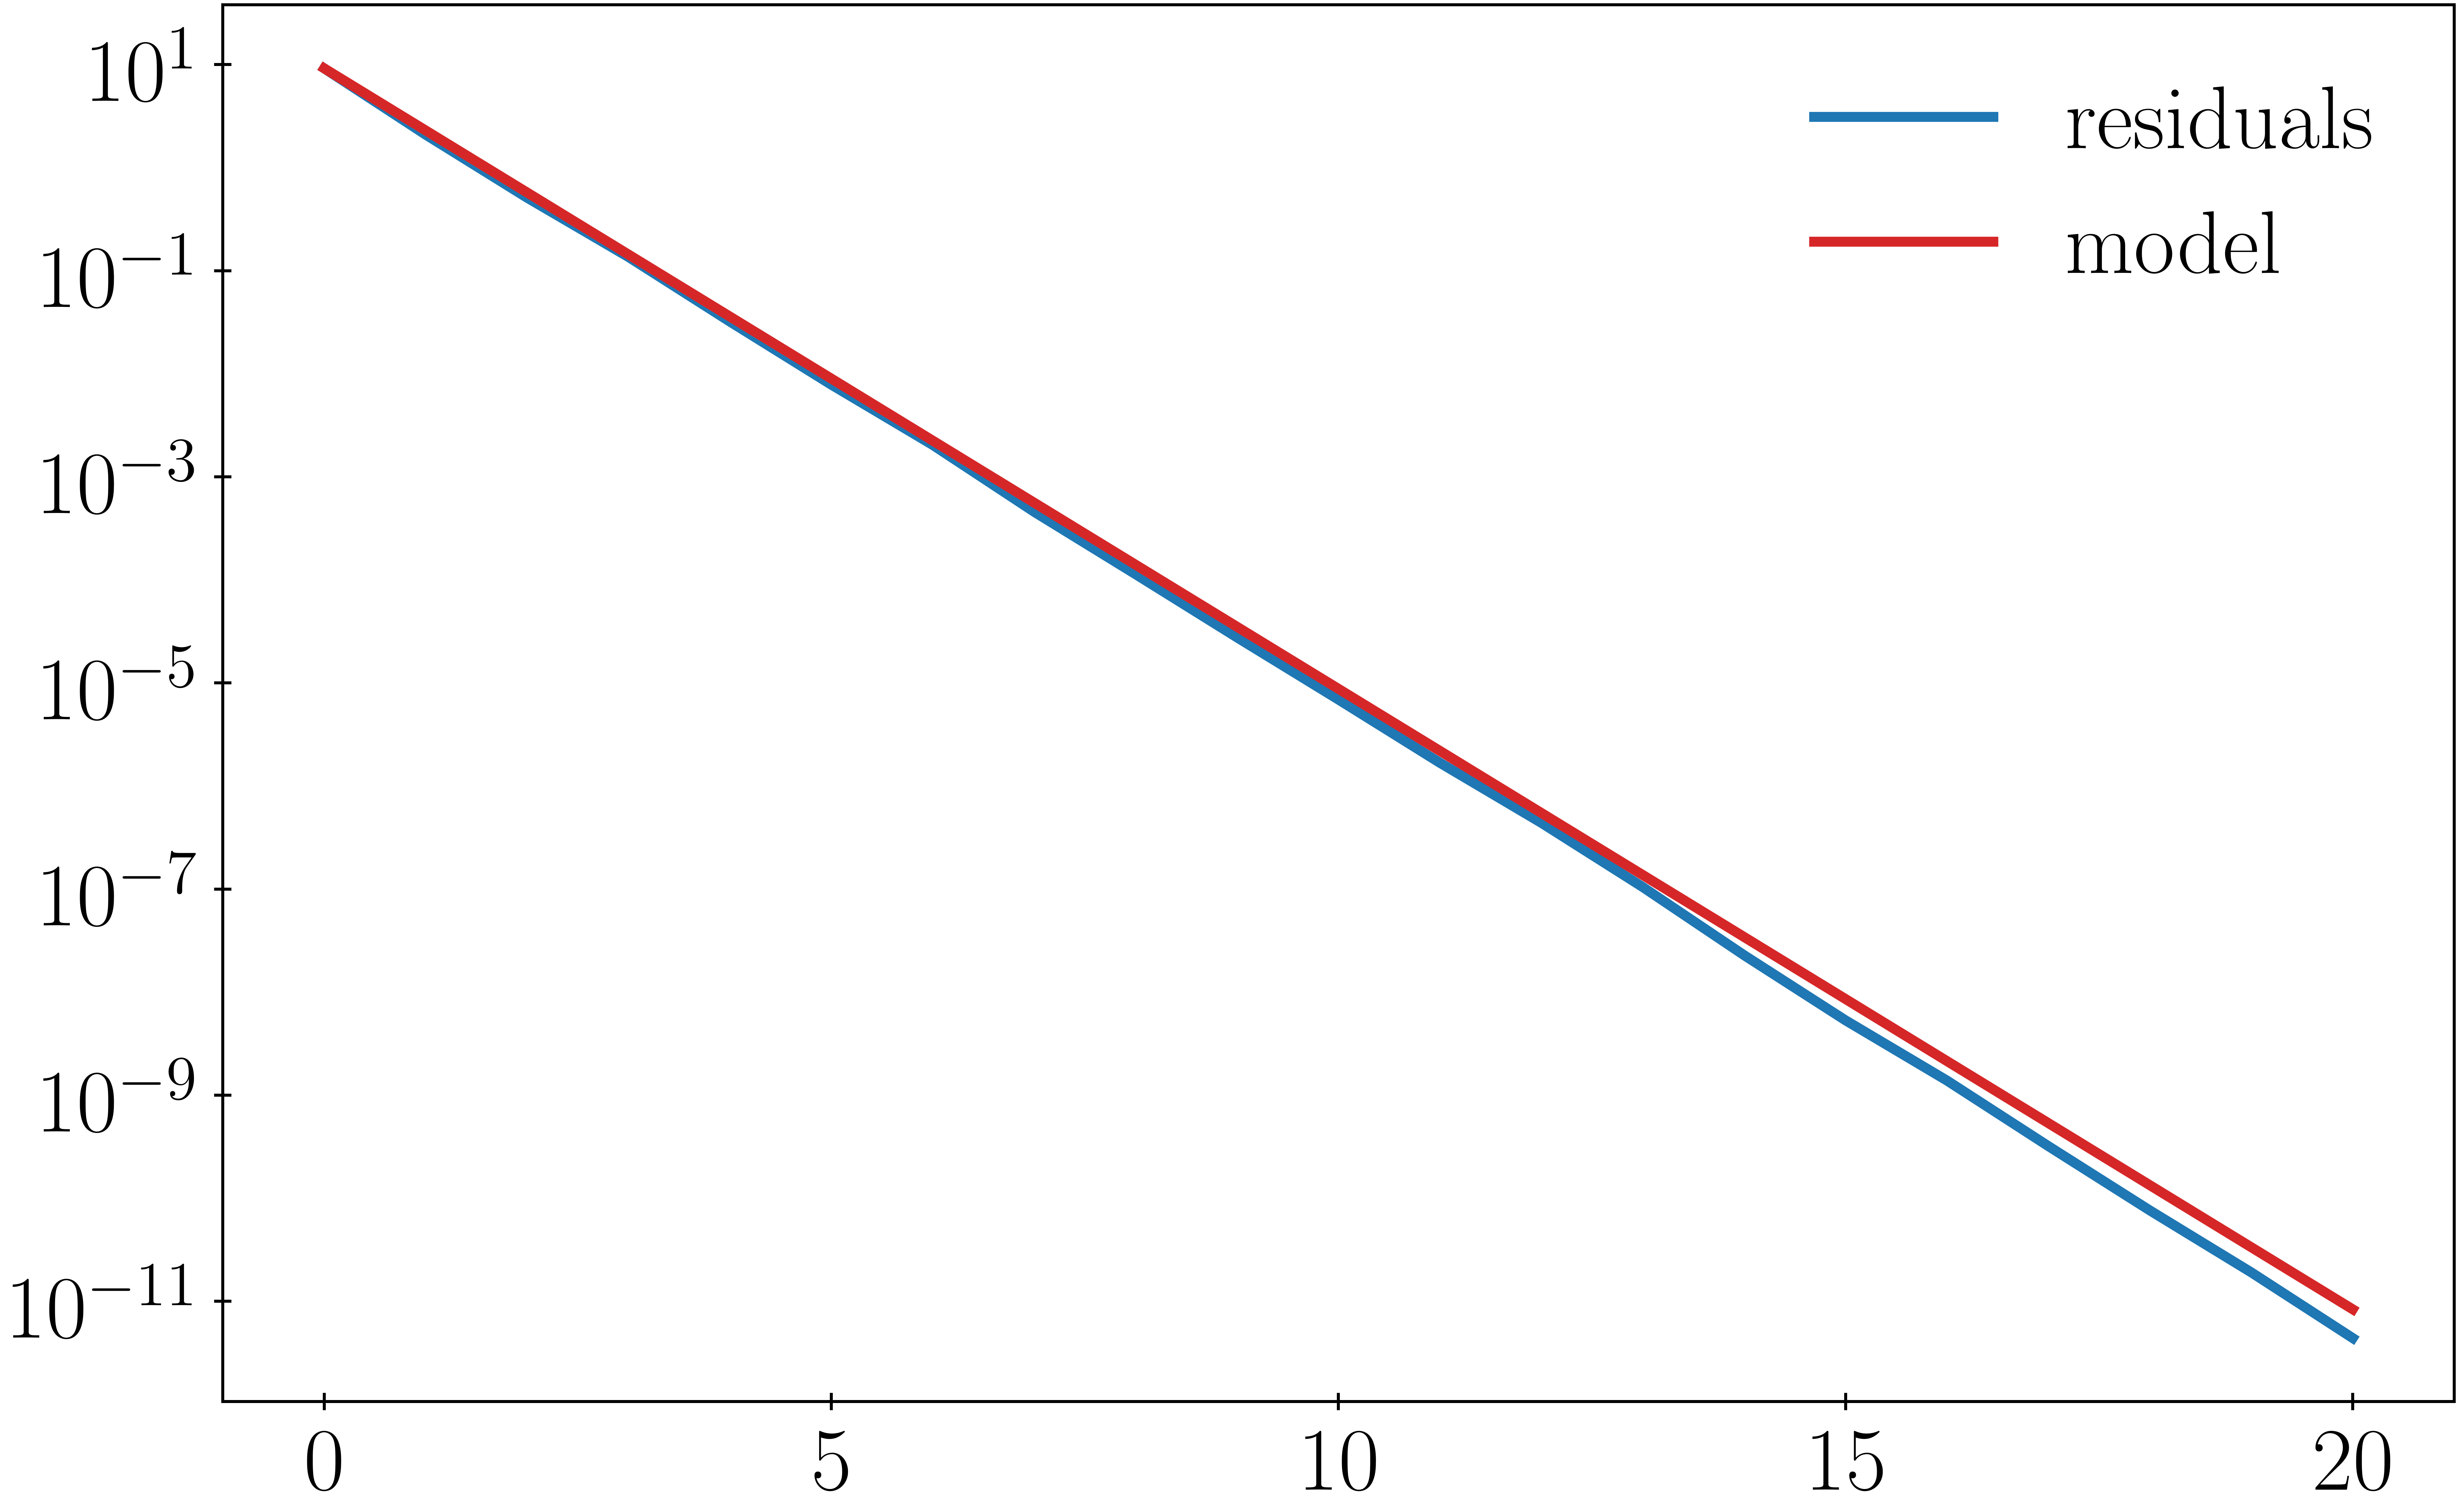

In [5]:
plt.semilogy(res, label='residuals')
ns = np.arange(0, len(res))
model = 4.0**(-ns)
model /= model[0]
model *= res[0]
plt.semilogy(ns, model, label='model')
plt.legend()

# Problem 2

In [6]:
A = A - 0.9*np.abs(W).min()*np.eye(m);
A = A.T.dot(A)
print(np.linalg.cond(A))
print(np.linalg.norm(A))
print(np.linalg.norm(np.linalg.inv(A)))

(W,V)=la.eig(A)
print('minimum eigenvalue: {}'.format(np.abs(W).min()))
print('maximum eigenvalue: {}'.format(np.abs(W).max()))

x = A.dot(np.ones((m,)))
b = A.dot(x)
x0 = np.random.rand(m)

286.5112673740937
11.715413830788725
243.53211482072027
minimum eigenvalue: 0.006999909479735222
maximum eigenvalue: 2.00555293654259


(np.float64(0.0), np.float64(3.0), np.float64(-1.0), np.float64(1.0))

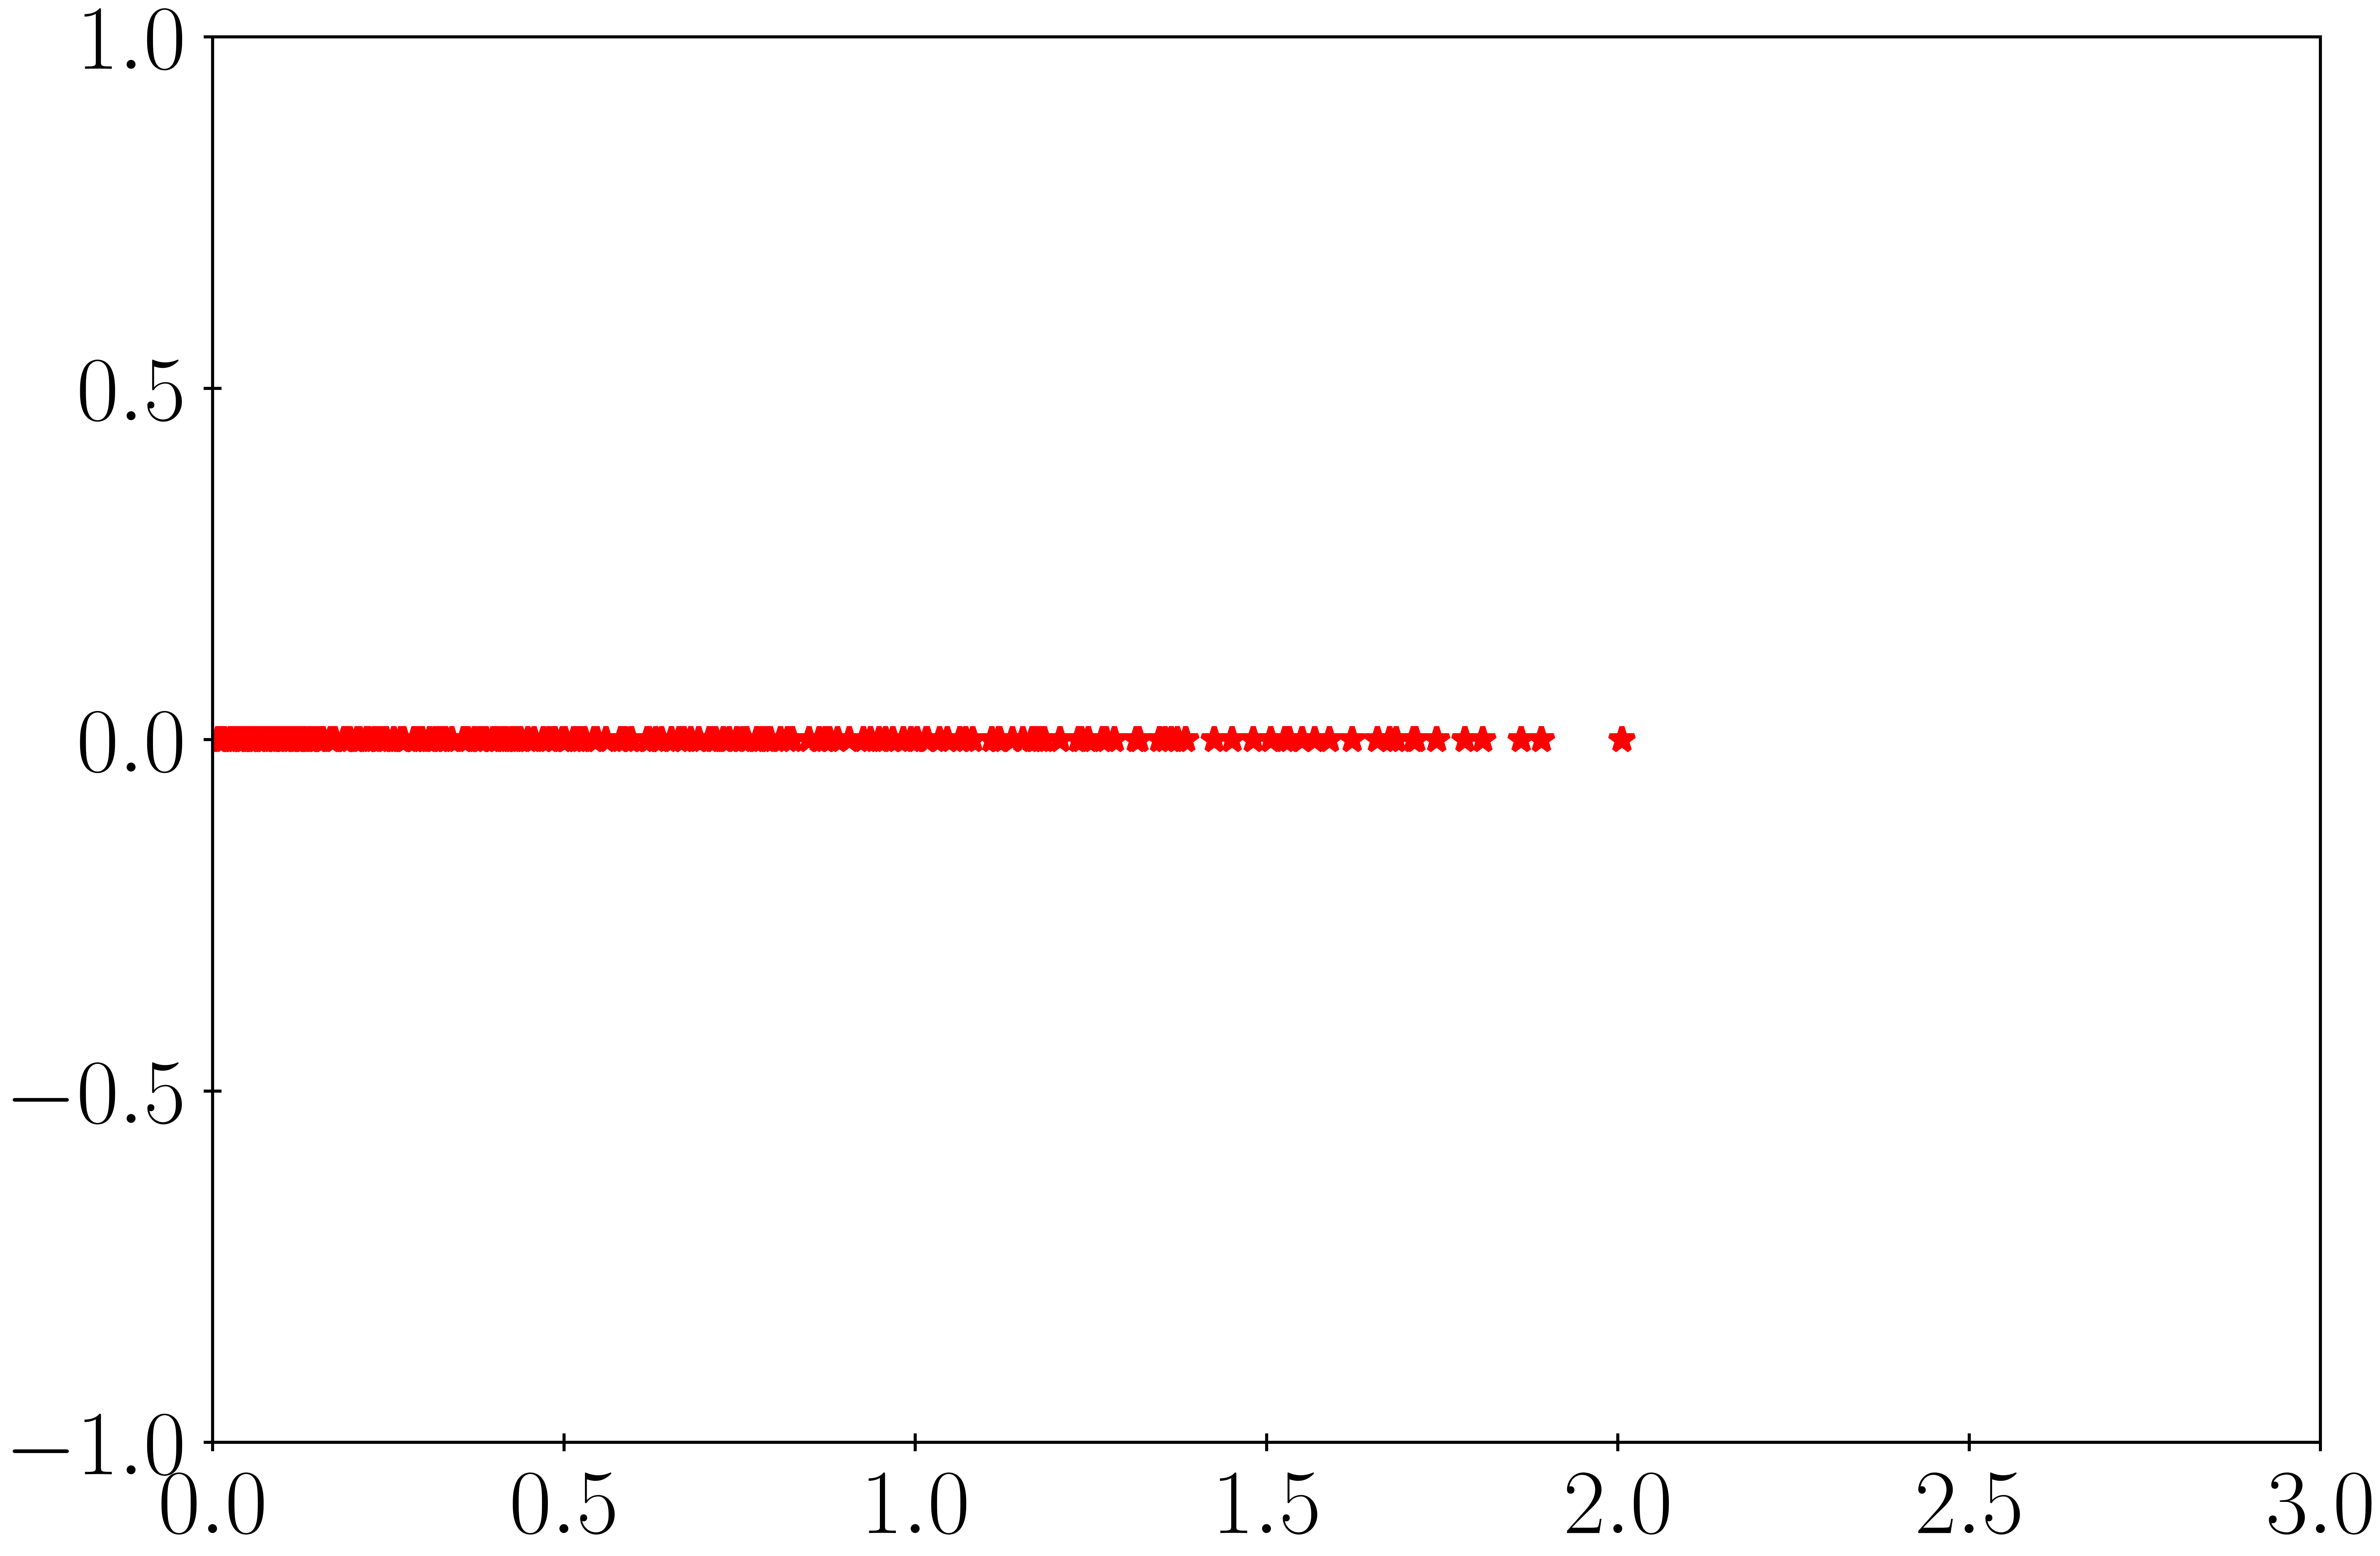

In [7]:
plt.plot(W.real, W.imag, '*r', ms=5)
plt.axis('scaled')
plt.axis([0,3, -1.0, 01.0])
#sns.despine(ax=plt.gca())

In [8]:
b = np.ones((A.shape[0],))
x0 = np.random.rand(len(b))

res = []
x = gmres(A, b, x0=x0, tol=1e-12, restrt=None, maxiter=200, residuals=res)

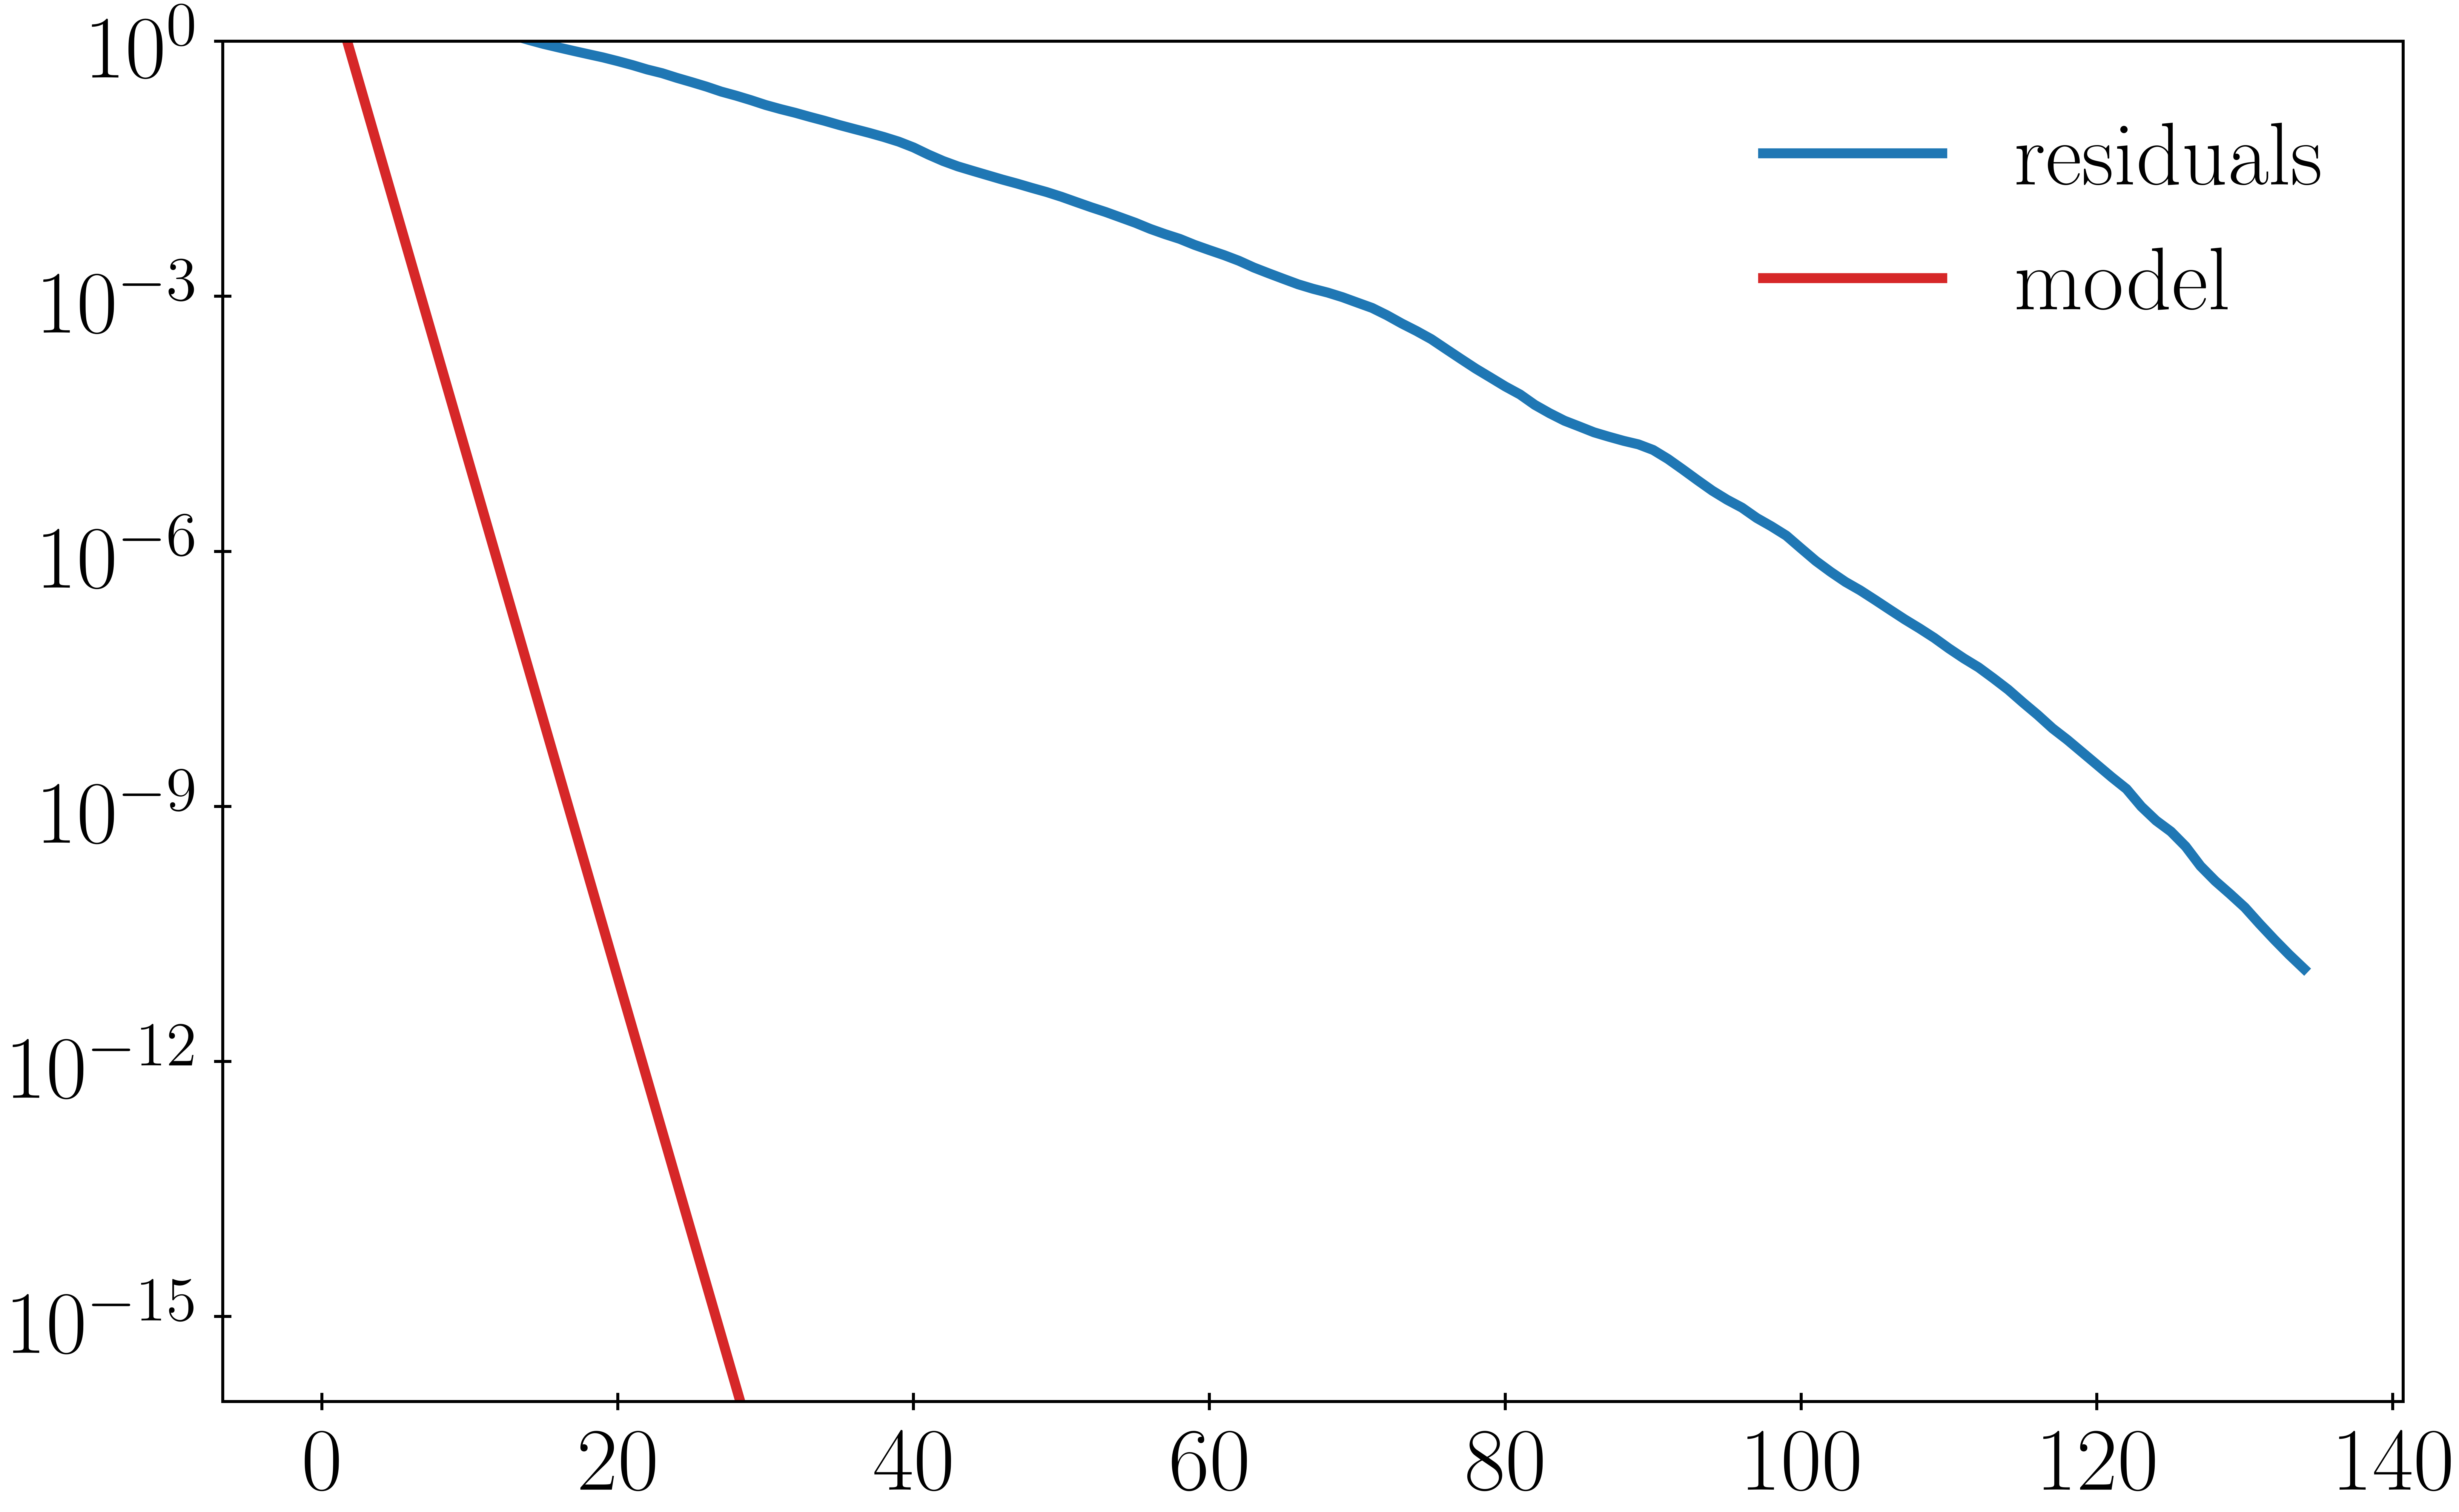

In [9]:
plt.semilogy(res, label='residuals')
ns = np.arange(0, len(res))
model = 4.0**(-ns)
model /= model[0]
model *= res[0]
plt.semilogy(ns, model, label='model')
plt.ylim(1e-16,1)
plt.legend()

In [10]:
A.shape

(200, 200)

# Problem 3

In [34]:
m = 200
A = (0.5/np.sqrt(m))*np.random.randn(m,m) + 2.0*np.eye(m) + 1j * 0 * np.eye(m)
theta = np.arange(0,m) * np.pi / (m - 1)
A += np.diag(-2.3 + 2*np.sin(theta) + 1j*np.cos(theta))
(W,V)=la.eig(A)
print('minimum eigenvalue: {}'.format(np.abs(W).min()))
print('maximum eigenvalue: {}'.format(np.abs(W).max()))

minimum eigenvalue: 0.832128765504369
maximum eigenvalue: 1.8838935459819595


In [35]:
np.linalg.cond(V)

np.float64(75.42937129611735)

condition of A: 4.0328106219484114


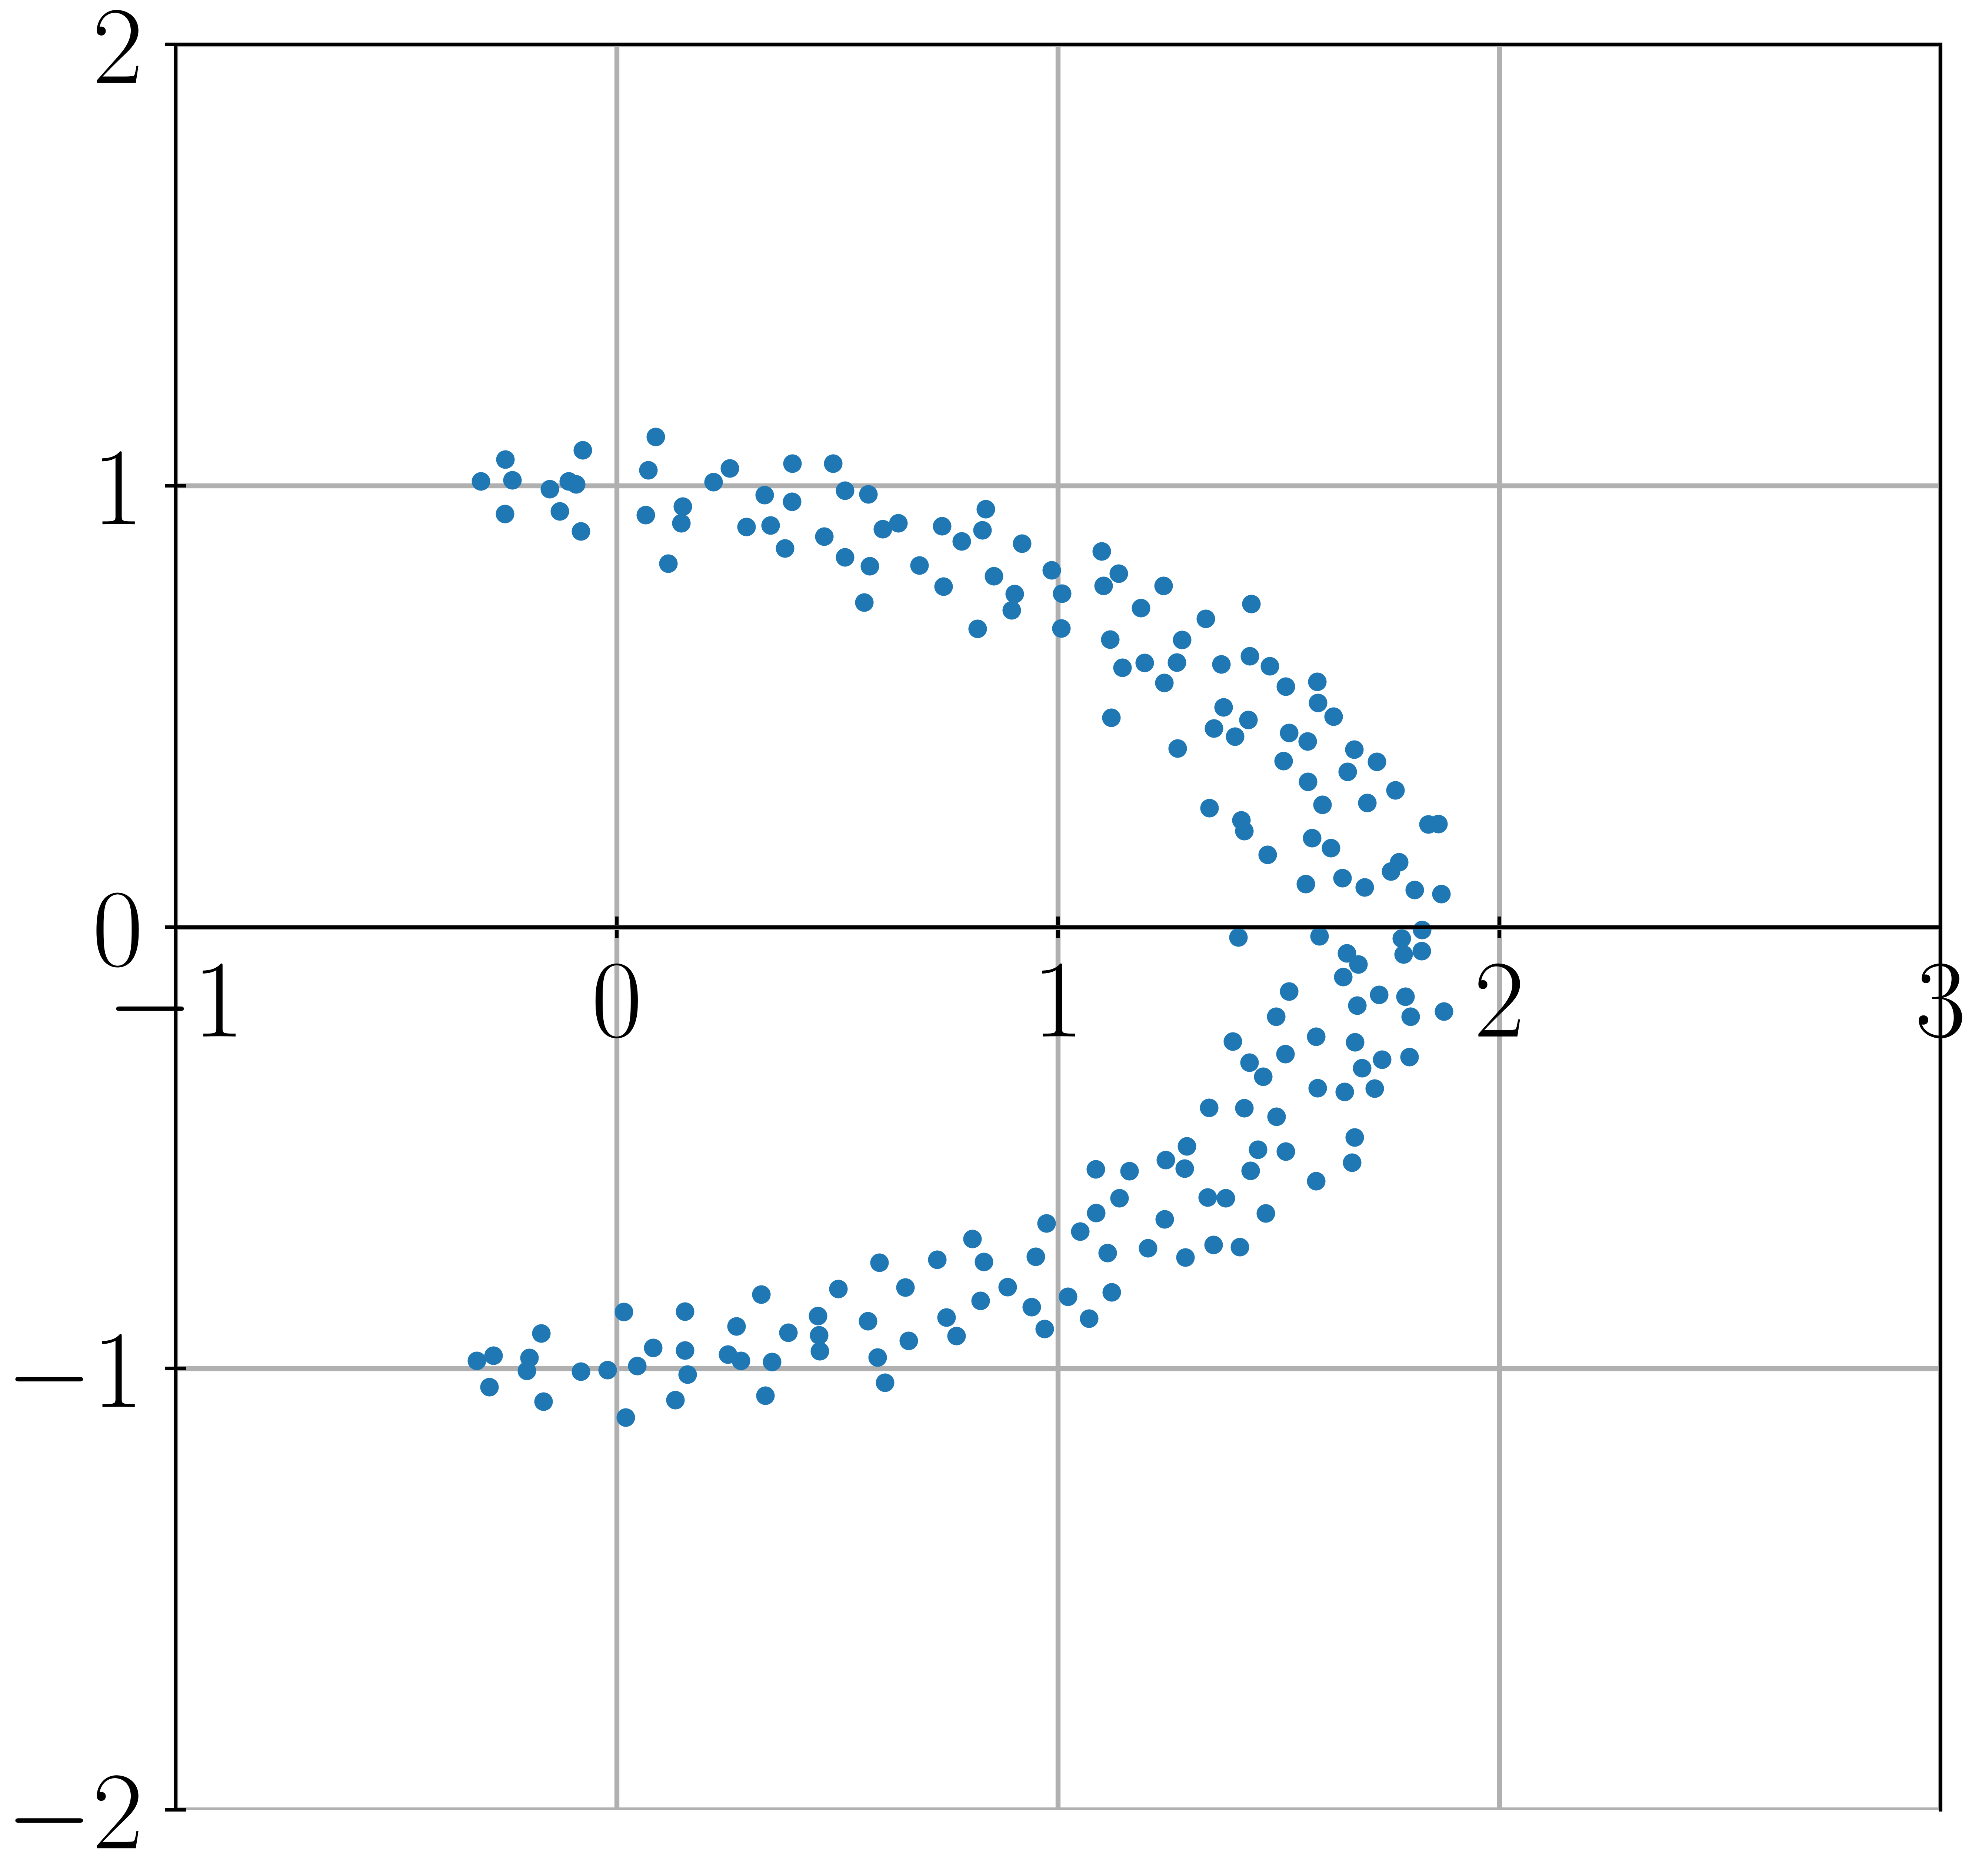

In [36]:
plt.plot(W.real, W.imag, 'o', ms=2)

plt.axis('scaled')
plt.axis([-1,3, -2, 2])
plt.gca().spines['bottom'].set_position('zero')
plt.grid(True)

print("condition of A:", np.linalg.cond(A))

In [37]:
b = np.ones((A.shape[0],))
x0 = np.random.rand(len(b))

res = []
x = gmres(A, b, x0=x0, tol=1e-12, restrt=None, maxiter=None, residuals=res)

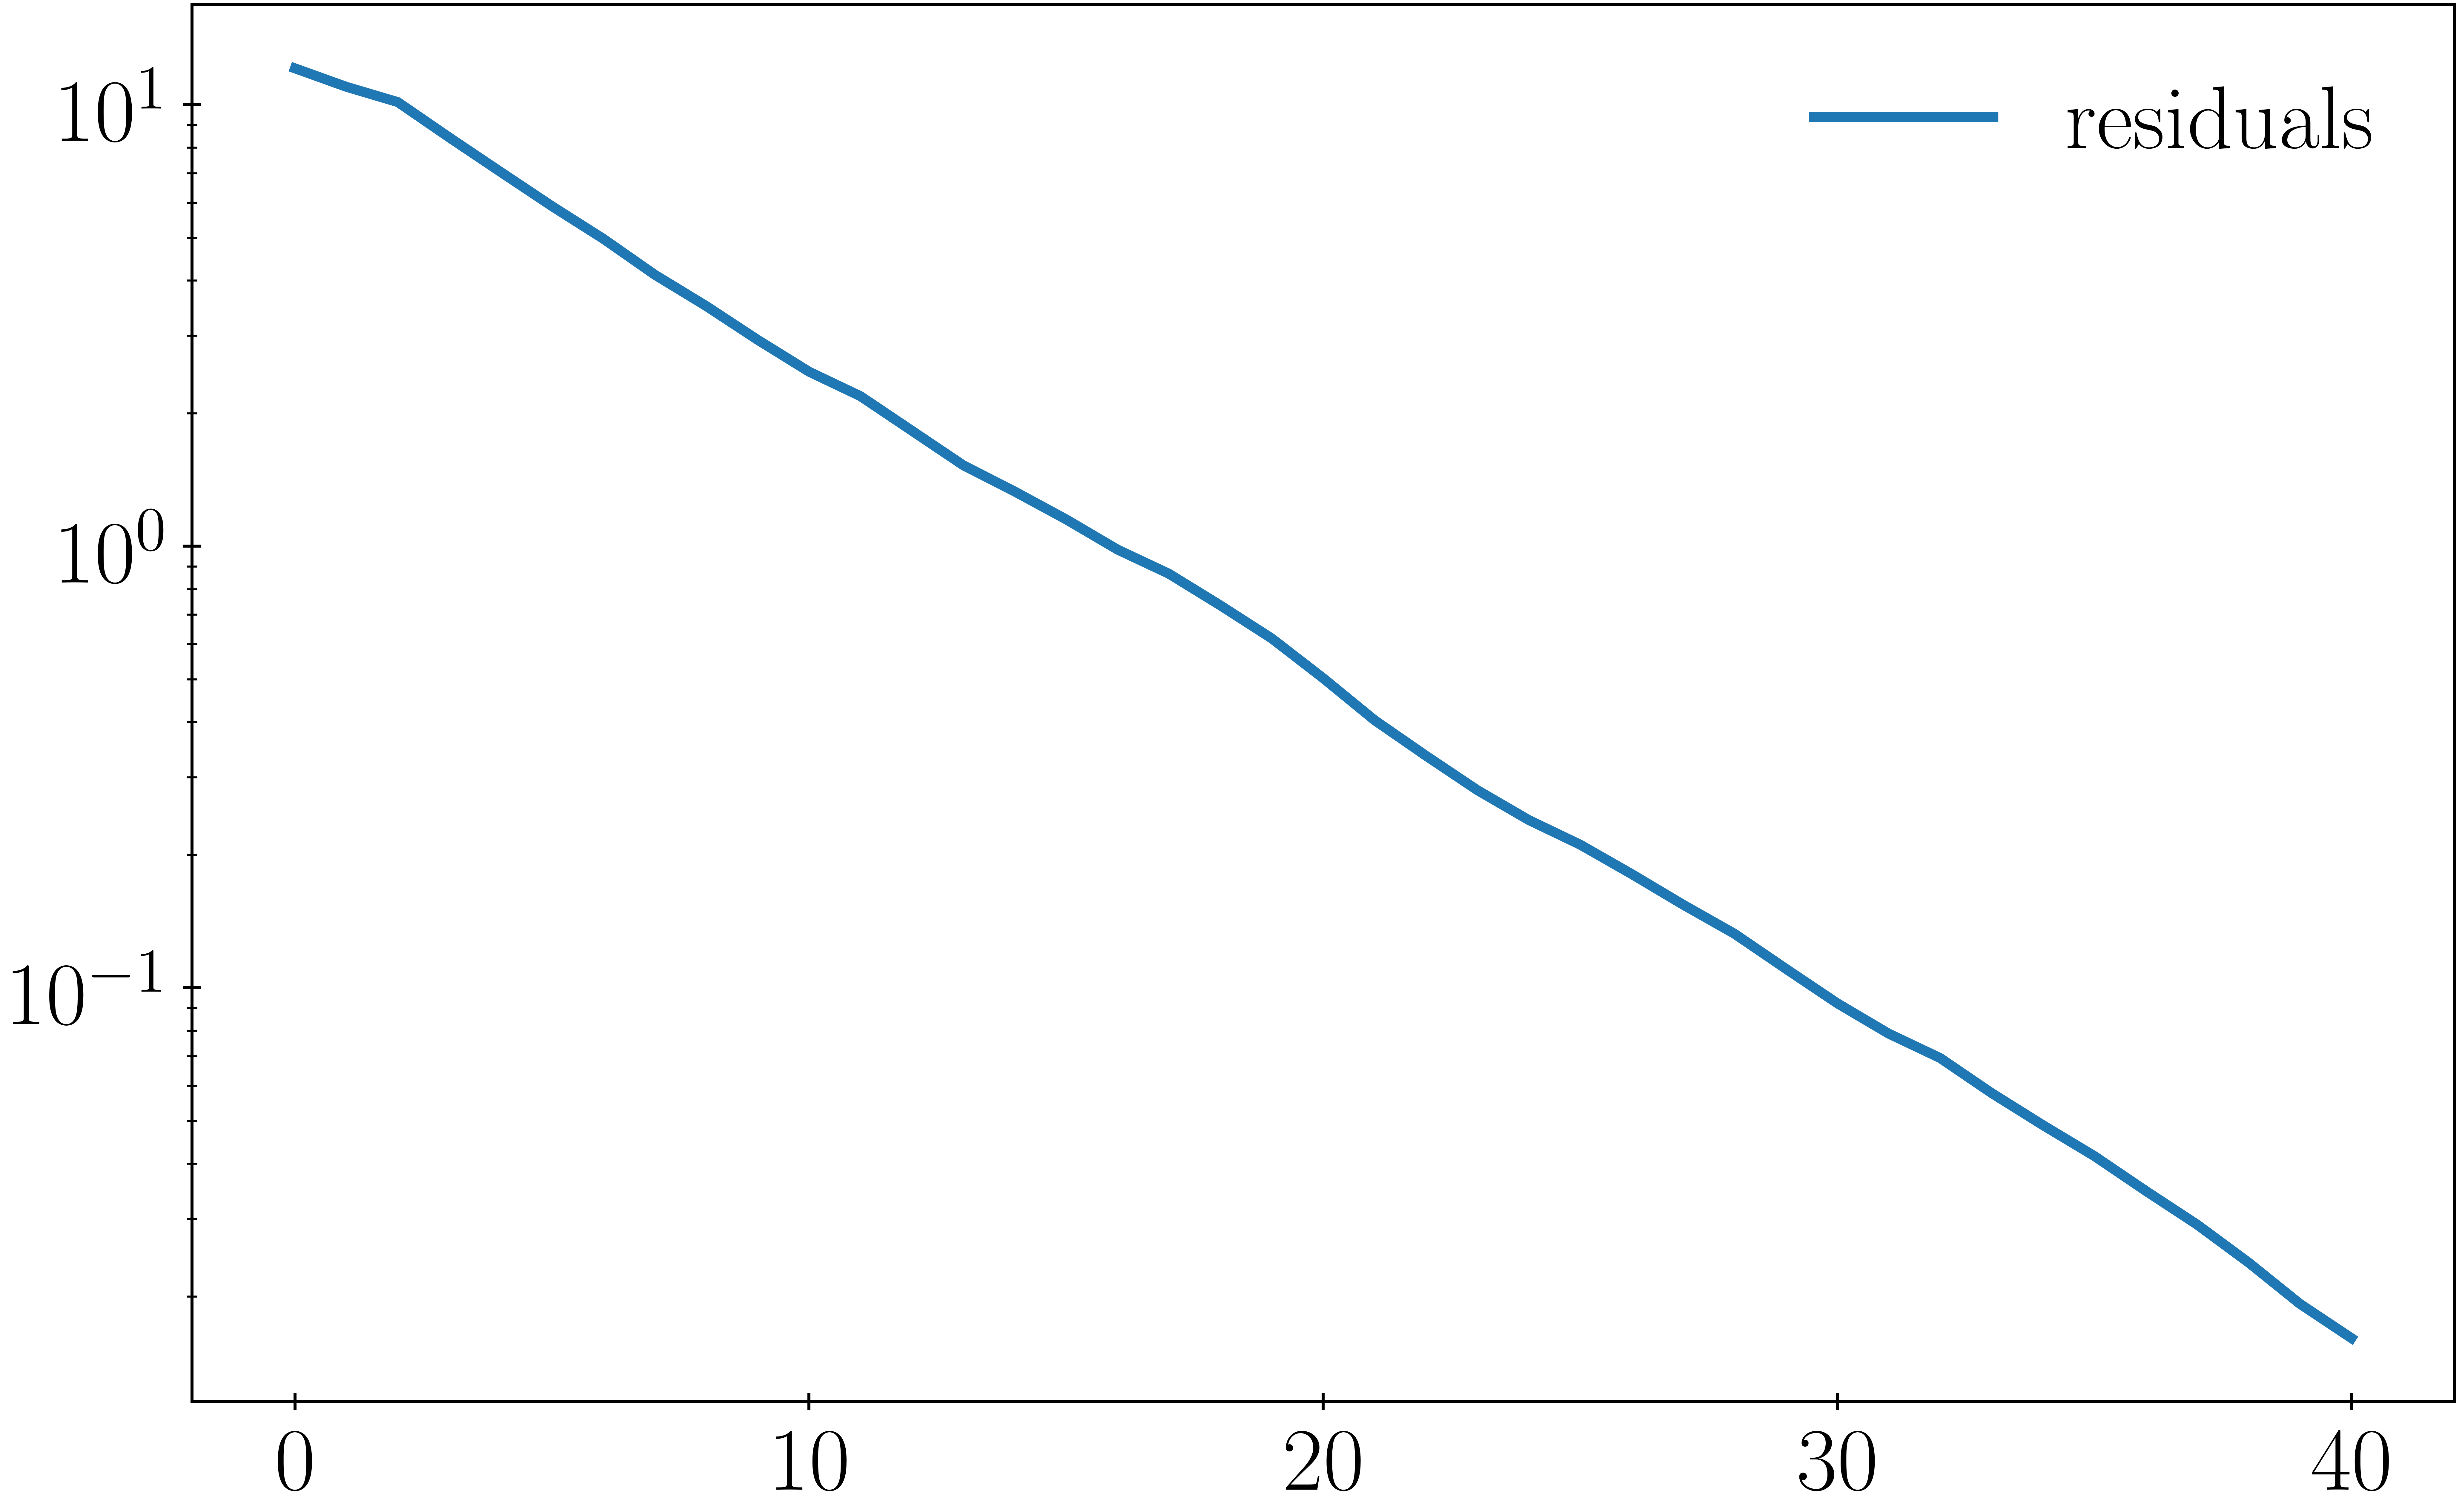

In [38]:
plt.semilogy(res, label='residuals')
ns = np.arange(0, len(res))
model = 4.0**(-ns)
model /= model[0]
model *= res[0]
#plt.semilogy(ns, model, label='model')
plt.legend()